In [ ]:
# Problem Statement: Intelligent Email / Report Automation

# In many organizations, employees spend a significant amount of time drafting emails and reports, especially for client communication, internal updates, and status reporting.

# The challenge is to:
# - Generate context-aware, professional emails automatically
# - Adapt tone based on audience (client, internal team, leadership)
# - Ensure consistency with company communication standards
# - Reduce manual effort while improving quality

# We will build an Agentic AI system using AutoGen where:
# - One agent analyzes the input context
# - One agent drafts the email
# - One agent reviews and refines the email for tone and clarity

# The agents collaborate autonomously to produce a final polished email.

# ============================================================
# USE CASE 1: Intelligent Email / Report Automation (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Import necessary modules
import os
from autogen import ConversableAgent

# Step 3: Set your OpenAI API Key (Make sure it's set in Colab secrets or environment)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: Define LLM configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0.5
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Flow)
# ============================================================

# Agent 1: Context Analyzer
context_analyzer = ConversableAgent(
    name="Context_Analyzer",
    system_message="""
    You are responsible for understanding the input context.
    Extract key details such as:
    - Purpose of email
    - Audience (client/internal)
    - Tone required (formal/informal)
    - Key points to include
    Output structured understanding.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Email Generator
email_generator = ConversableAgent(
    name="Email_Generator",
    system_message="""
    You are an expert email writer.
    Based on the analyzed context, draft a professional email.
    Ensure:
    - Clear structure
    - Proper tone
    - Business communication standards
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Email Reviewer (Critic)
email_reviewer = ConversableAgent(
    name="Email_Reviewer",
    system_message="""
    You are a senior reviewer.
    Your job is to:
    - Improve clarity
    - Fix tone issues
    - Ensure professionalism
    - Remove ambiguity

    Return FINAL polished email.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Create Agentic Workflow (Sequential Multi-Agent Flow)
# ============================================================

# Input from user (Business Scenario)
user_input = """
Client escalation: Delivery delayed by 2 days due to internal dependency.
Need to send a professional apology email with revised timeline.
Audience: External client
Tone: Formal and reassuring
"""

# Step 6.1: Context Analysis
context_output = context_analyzer.generate_reply(
    messages=[{"role": "user", "content": user_input}]
)

# Step 6.2: Email Drafting
draft_output = email_generator.generate_reply(
    messages=[{"role": "user", "content": context_output}]
)

# Step 6.3: Review & Finalization
final_output = email_reviewer.generate_reply(
    messages=[{"role": "user", "content": draft_output}]
)

# ============================================================
# Step 7: Display Final Output
# ============================================================

print("========== FINAL EMAIL OUTPUT ==========\n")
print(final_output)

========== FINAL EMAIL OUTPUT ==========

Subject: Revised Delivery Timeline and Apologies for Delay

Dear [Client's Name],

I trust this message finds you well. I am writing to address the delay in the delivery of your recent order with us.

Firstly, please accept our heartfelt apologies for this inconvenience. We fully understand the disruption this delay may have caused, and we deeply regret the unforeseen circumstances that have led to this situation.

The delay resulted from an unexpected internal issue that affected our normal operational flow. Rest assured, we have been working relentlessly to rectify this, and significant progress has been made.

Considering the current circumstances, we have revised our delivery timeline. We now expect your order to be dispatched by [insert new delivery date]. Our team is working around the clock to adhere to this new timeline and ensure your order is delivered as quickly as possible.

To mitigate such issues in the future, we have implemented

In [ ]:
# Problem Statement: Data Query Assistant (SQL / BI)

# In many organizations, business users (sales, operations, finance teams) need insights from data but lack SQL or technical skills.

# The challenge is to:
# - Convert natural language questions into SQL queries
# - Ensure queries are correct and optimized
# - Execute queries safely on a database
# - Interpret results into business-friendly insights

# We will build an Agentic AI system using AutoGen where:
# - One agent understands the business question
# - One agent generates SQL query
# - One agent executes the query
# - One agent interprets the result into insights

# The agents collaborate autonomously to deliver actionable insights.

# ============================================================
# USE CASE 2: Data Query Assistant (SQL / BI) - Agentic AI
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Import required modules
import os
import sqlite3 # For simulating a database
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Configuration
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Create Sample Database (Simulating Real Business DB)
# ============================================================

conn = sqlite3.connect("sales.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    region TEXT,
    product TEXT,
    revenue INTEGER
)
""")

# Insert sample data
cursor.executemany("""
INSERT INTO sales (region, product, revenue) VALUES (?, ?, ?)
""", [
    ("North", "Laptop", 50000),
    ("South", "Mobile", 30000),
    ("North", "Tablet", 20000),
    ("West", "Laptop", 40000),
    ("South", "Laptop", 35000)
])

conn.commit()

# ============================================================
# Step 6: Define Agents (Pure Agentic Flow)
# ============================================================

# Agent 1: Business Understanding Agent
business_agent = ConversableAgent(
    name="Business_Interpreter",
    system_message="""
    You understand business questions.
    Convert the user query into a clear analytical requirement.
    Identify:
    - Metrics (e.g., revenue, count)
    - Filters (region, product)
    - Aggregations (sum, avg)
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: SQL Generator Agent
sql_agent = ConversableAgent(
    name="SQL_Generator",
    system_message="""
    You are an expert SQL developer.
    Based on the requirement, generate a correct SQLite SQL query.
    Only return SQL query.
    Table name: sales (columns: id, region, product, revenue)
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: SQL Executor (No LLM)
def execute_sql(query):
    try:
        result = cursor.execute(query).fetchall()
        # For debugging, you can print the result here
        print("SQL Execution Result (Raw):", result)
        return str(result)
    except Exception as e:
        return f"Error: {e}"

executor_agent = ConversableAgent(
    name="SQL_Executor",
    llm_config=False,
    human_input_mode="NEVER",
    function_map={"execute_sql": execute_sql}
)

# Agent 4: Insight Generator
insight_agent = ConversableAgent(
    name="Insight_Generator",
    system_message="""
    You are a business analyst.
    Convert SQL results into meaningful insights.
    Keep it simple, clear, and business-friendly.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

user_query = "What is total revenue from Laptop sales in North region?"
# user_query = "What is total revenue from sales in North region?"

# Step 7.1: Understand business requirement
business_output = business_agent.generate_reply(
    messages=[{"role": "user", "content": user_query}]
)
print("\nBusiness Understanding Output:\n", business_output)

# Step 7.2: Generate SQL
sql_query = sql_agent.generate_reply(
    messages=[{"role": "user", "content": business_output}]
)
print("\nGenerated SQL Query:\n", sql_query)

# Step 7.3: Execute SQL
execution_result = execute_sql(sql_query)
print("\nSQL Execution Result:\n", execution_result)

# Step 7.4: Generate Insight
final_insight = insight_agent.generate_reply(
    messages=[{"role": "user", "content": execution_result}]
)

# ============================================================
# Step 8: Output
# ============================================================

print("\n========== FINAL BUSINESS INSIGHT ==========\n")
print(final_insight)


Business Understanding Output:
 - Metrics: Revenue
- Filters: Product (Laptop), Region (North)
- Aggregations: Sum

Generated SQL Query:
 SELECT SUM(revenue) 
FROM sales 
WHERE product = 'Laptop' AND region = 'North'
SQL Execution Result (Raw): [(50000,)]

SQL Execution Result:
 [(50000,)]

========== FINAL BUSINESS INSIGHT ==========

The SQL query result indicates that there are 50,000 records in the dataset. This could represent a variety of things depending on the context, such as the number of transactions, customers, products, etc. in the company's database. 

TERMINATE


In [ ]:
# Problem Statement: Resume Screening System (HR)

# Organizations receive a large volume of resumes for job openings, making manual screening time-consuming and inconsistent.

# The challenge is to:
# - Extract structured information from resumes
# - Match candidate skills with job requirements
# - Score candidates objectively
# - Validate the decision before shortlisting

# We will build an Agentic AI system using AutoGen where:
# - One agent extracts candidate details from resume
# - One agent compares with job description
# - One agent scores the candidate
# - One agent reviews and validates the decision

# The agents collaborate autonomously to produce a final hiring recommendation.

# ============================================================
# USE CASE 3: Resume Screening System (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Resume Extractor
extractor_agent = ConversableAgent(
    name="Resume_Extractor",
    system_message="""
    You extract structured information from resume text.
    Extract:
    - Skills
    - Experience (years)
    - Key technologies
    - Domain
    Return in structured bullet format.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Job Matcher
matcher_agent = ConversableAgent(
    name="Job_Matcher",
    system_message="""
    You compare candidate profile with job description.
    Identify:
    - Matching skills
    - Missing skills
    - Overall fit (High / Medium / Low)
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Scoring Agent
scoring_agent = ConversableAgent(
    name="Scoring_Agent",
    system_message="""
    You assign a score from 0 to 100 based on:
    - Skill match
    - Experience relevance
    - Domain fit
    Provide reasoning for score.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Critic / Reviewer Agent
review_agent = ConversableAgent(
    name="Review_Agent",
    system_message="""
    You are a senior hiring manager.
    Validate the scoring and matching.
    Give FINAL decision:
    - Shortlist / Reject / Consider Later
    Provide justification.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Data (Simulating Real Scenario)
# ============================================================

resume_text = """
Candidate: John Doe
Experience: 5 years
Skills: Python, Machine Learning, SQL, Pandas
Domain: E-commerce analytics
Worked on recommendation systems and sales forecasting
"""

job_description = """
Role: Data Scientist
Required Skills: Python, Machine Learning, Deep Learning, SQL
Experience: 4+ years
Domain: Any analytics domain preferred
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Extract Resume Info
extracted_info = extractor_agent.generate_reply(
    messages=[{"role": "user", "content": resume_text}]
)
print("\nExtracted Resume Information:\n", extracted_info)

# Step 7.2: Match with Job Description
match_input = f"Candidate Info:\n{extracted_info}\n\nJob Description:\n{job_description}"
match_result = matcher_agent.generate_reply(
    messages=[{"role": "user", "content": match_input}]
)
print("\nMatch Result:\n", match_result)

# Step 7.3: Score Candidate
score_result = scoring_agent.generate_reply(
    messages=[{"role": "user", "content": match_result}]
)
print("\nScore Result:\n", score_result)

# Step 7.4: Final Review
final_decision = review_agent.generate_reply(
    messages=[{"role": "user", "content": score_result}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nFinal Decision:\n", final_decision)



Extracted Resume Information:
 - Skills: Python, Machine Learning, SQL, Pandas
- Experience: 5 years
- Key Technologies: Recommendation systems, Sales forecasting
- Domain: E-commerce analytics

Match Result:
 Matching Skills:
- Python
- Machine Learning
- SQL
- Experience (5 years)
- Domain (E-commerce analytics)

Missing Skills:
- Deep Learning

Overall Fit: High

The candidate has most of the required skills and exceeds the required experience. The only missing skill is Deep Learning, but depending on the importance of this skill for the role, the candidate could potentially learn it on the job. The candidate's experience in E-commerce analytics is also a plus, as the job description mentions a preference for any analytics domain.

Score Result:
 Score: 85

Reasoning: The candidate has a strong match in terms of skills, experience, and domain fit. The only missing skill is Deep Learning, which reduces the score slightly. However, the candidate's strong experience and domain fit mak

In [ ]:
# Problem Statement: Customer Support Auto-Resolution System

# Organizations receive a large number of customer support tickets daily, leading to delays in response and increased operational cost.

# The challenge is to:
# - Understand customer intent from tickets
# - Retrieve relevant knowledge base information
# - Generate accurate responses
# - Decide whether to resolve or escalate

# We will build an Agentic AI system using AutoGen where:
# - One agent classifies the intent of the ticket
# - One agent retrieves relevant knowledge (simulated RAG)
# - One agent generates the response
# - One agent decides whether to resolve or escalate

# The agents collaborate autonomously to handle customer queries efficiently.

# ============================================================
# USE CASE 4: Customer Support Auto-Resolution System
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Simulated Knowledge Base (RAG-lite)
# ============================================================

knowledge_base = {
    "refund": "Refunds are processed within 5-7 business days after approval.",
    "delay": "Delivery delays may occur due to logistics or supplier issues. Updated timelines will be shared.",
    "login": "If you are unable to login, please reset your password using the 'Forgot Password' option."
}

def retrieve_knowledge(query):
    for key in knowledge_base:
        if key in query.lower():
            return knowledge_base[key]
    return "No relevant information found."

# ============================================================
# Step 6: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Intent Classifier
intent_agent = ConversableAgent(
    name="Intent_Agent",
    system_message="""
    Identify customer intent from the query.
    Possible intents:
    - refund
    - delay
    - login
    - other
    Return only intent.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Knowledge Retriever
retriever_agent = ConversableAgent(
    name="Retriever_Agent",
    llm_config=False,
    human_input_mode="NEVER",
    function_map={"retrieve": retrieve_knowledge}
)

# Agent 3: Response Generator
response_agent = ConversableAgent(
    name="Response_Agent",
    system_message="""
    Generate a professional customer support response using retrieved knowledge.
    Be polite, clear, and helpful.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Escalation Decision Agent
decision_agent = ConversableAgent(
    name="Decision_Agent",
    system_message="""
    Decide:
    - RESOLVE → if answer is sufficient
    - ESCALATE → if unclear or insufficient info

    Provide final decision with justification.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Input Ticket
# ============================================================

customer_query = "My order is delayed and I have not received any update."

# ============================================================
# Step 8: Agentic Workflow
# ============================================================

# Step 8.1: Intent Detection
intent = intent_agent.generate_reply(
    messages=[{"role": "user", "content": customer_query}]
)
print("\nDetected Intent:\n", intent)

# Step 8.2: Retrieve Knowledge
retrieved_info = retrieve_knowledge(intent)
print("\nRetrieved Knowledge:\n", retrieved_info)

# Step 8.3: Generate Response
response_input = f"Customer Query: {customer_query}\nKnowledge: {retrieved_info}"
response = response_agent.generate_reply(
    messages=[{"role": "user", "content": response_input}]
)
print("\nGenerated Response:\n", response)

# Step 8.4: Decision Making
decision_input = f"Response: {response}"
final_decision = decision_agent.generate_reply(
    messages=[{"role": "user", "content": decision_input}]
)
# ============================================================
# Step 9: Output
# ============================================================
print("\nFinal Decision:\n", final_decision)


Detected Intent:
 delay

Retrieved Knowledge:
 Delivery delays may occur due to logistics or supplier issues. Updated timelines will be shared.

Generated Response:
 Dear Customer,

I'm sorry to hear about the delay in your order. Sometimes, unforeseen circumstances such as logistics or supplier issues can cause delays. We understand how important it is for you to receive your order on time and we sincerely apologize for any inconvenience caused.

Please be assured that we are working diligently to resolve this issue. We will provide you with updated timelines as soon as they are available. 

Thank you for your patience and understanding. If you have any other questions or concerns, please don't hesitate to reach out.

Best Regards,
[Your Name]

Final Decision:
 RESOLVE

The response is sufficient as it addresses the customer's concern about the delay in their order. It also reassures the customer that the issue is being worked on and that they will be updated as soon as possible. The

In [ ]:
# Problem Statement: Sales Proposal Generator

# Sales teams spend significant time creating customized proposals for each client, including understanding requirements, drafting content, estimating pricing, and ensuring compliance.

# The challenge is to:
# - Analyze client requirements quickly
# - Generate tailored proposal content
# - Estimate pricing logically
# - Ensure compliance with company policies

# We will build an Agentic AI system using AutoGen where:
# - One agent analyzes client requirements
# - One agent generates proposal content
# - One agent estimates pricing
# - One agent reviews for compliance and finalizes the proposal

# The agents collaborate autonomously to produce a client-ready proposal.

# ============================================================
# USE CASE 5: Sales Proposal Generator (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0.5
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Requirement Analyzer
requirement_agent = ConversableAgent(
    name="Requirement_Analyzer",
    system_message="""
    Analyze client requirements and extract:
    - Business problem
    - Scope of work
    - Key deliverables
    - Timeline expectations
    Return structured output.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Proposal Content Generator
proposal_agent = ConversableAgent(
    name="Proposal_Generator",
    system_message="""
    Generate a professional sales proposal including:
    - Introduction
    - Understanding of requirements
    - Proposed solution
    - Deliverables
    - Timeline
    Ensure clarity and persuasive tone.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Pricing Agent
pricing_agent = ConversableAgent(
    name="Pricing_Agent",
    system_message="""
    Estimate pricing based on:
    - Scope complexity
    - Timeline
    - Deliverables

    Provide:
    - Cost estimate
    - Justification
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Compliance & Review Agent
review_agent = ConversableAgent(
    name="Compliance_Reviewer",
    system_message="""
    Review the proposal for:
    - Professional tone
    - Completeness
    - Logical pricing
    - No overpromising

    Provide FINAL proposal.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input (Real Business Scenario)
# ============================================================

client_requirement = """
Client is a retail company.
They want an AI solution for demand forecasting and inventory optimization.
Timeline: 8 weeks
Expect dashboards and predictive models.
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Analyze Requirements
requirement_output = requirement_agent.generate_reply(
    messages=[{"role": "user", "content": client_requirement}]
)
print("\nAnalyzed Requirements:\n", requirement_output)

# Step 7.2: Generate Proposal Content
proposal_output = proposal_agent.generate_reply(
    messages=[{"role": "user", "content": requirement_output}]
)
print("\nGenerated Proposal Content:\n", proposal_output)

# Step 7.3: Generate Pricing
pricing_output = pricing_agent.generate_reply(
    messages=[{"role": "user", "content": requirement_output}]
)
print("\nGenerated Pricing:\n", pricing_output)

# Step 7.4: Combine Content + Pricing
combined_input = f"""
Proposal Content:
{proposal_output}

Pricing:
{pricing_output}
"""

# Step 7.5: Final Review
final_proposal = review_agent.generate_reply(
    messages=[{"role": "user", "content": combined_input}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nFinal Proposal:\n", final_proposal)


Analyzed Requirements:
 - Business Problem: The client, a retail company, is facing issues with demand forecasting and inventory optimization.

- Scope of Work: The project involves developing an AI solution that can accurately forecast demand and optimize inventory management. This would involve understanding the client's current inventory and sales data, developing predictive models for demand forecasting, and creating an optimization algorithm for inventory management.

- Key Deliverables: The key deliverables for this project would be:
  1. An AI-based demand forecasting model.
  2. An inventory optimization solution.
  3. Dashboards that display key metrics and insights derived from the models.

- Timeline Expectations: The client expects the project to be completed in 8 weeks.

Generated Proposal Content:
 **Introduction**

Dear [Client's Name],

We are excited to present our proposal for your consideration. We understand that in the dynamic world of retail, accurate demand fore

In [ ]:
# Problem Statement: Incident Management System (IT / Operations)

# Organizations frequently face production issues such as system failures, API errors, and performance bottlenecks. Identifying root cause and resolving incidents quickly is critical.

# The challenge is to:
# - Analyze logs and error messages
# - Identify root cause of the issue
# - Suggest fixes or remediation steps
# - Validate whether the fix is correct

# We will build an Agentic AI system using AutoGen where:
# - One agent analyzes logs
# - One agent identifies root cause
# - One agent suggests a fix
# - One agent validates the fix

# The agents collaborate autonomously to resolve incidents efficiently.

# ============================================================
# USE CASE 6: Incident Management System (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Log Analyzer
log_analyzer = ConversableAgent(
    name="Log_Analyzer",
    system_message="""
    Analyze system logs and extract:
    - Error type
    - Possible issue
    - Affected component
    Return structured summary.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Root Cause Analyzer
rca_agent = ConversableAgent(
    name="Root_Cause_Agent",
    system_message="""
    Identify root cause of the issue based on log analysis.
    Be precise and technical.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Fix Generator
fix_agent = ConversableAgent(
    name="Fix_Agent",
    system_message="""
    Suggest actionable fix steps.
    Include:
    - Configuration changes
    - Code fixes (if applicable)
    - Operational steps
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Validation Agent
validator_agent = ConversableAgent(
    name="Validation_Agent",
    system_message="""
    Validate the proposed fix:
    - Will it solve the issue?
    - Any risks?
    Provide FINAL recommendation.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input (Simulated Production Log)
# ============================================================

log_data = """
ERROR: Database connection timeout after 30 seconds.
Service: Order Processing API
Recent changes: Increased traffic during sale
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Log Analysis
analysis_output = log_analyzer.generate_reply(
    messages=[{"role": "user", "content": log_data}]
)
print("\nLog Analysis Output:\n", analysis_output)

# Step 7.2: Root Cause Identification
rca_output = rca_agent.generate_reply(
    messages=[{"role": "user", "content": analysis_output}]
)
print("\nRoot Cause Analysis Output:\n", rca_output)

# Step 7.3: Fix Suggestion
fix_output = fix_agent.generate_reply(
    messages=[{"role": "user", "content": rca_output}]
)
print("\nFix Suggestion Output:\n", fix_output)

# Step 7.4: Validation
final_output = validator_agent.generate_reply(
    messages=[{"role": "user", "content": fix_output}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nFinal Validation Output:\n", final_output)


Log Analysis Output:
 - Error type: Database Connection Timeout
- Possible issue: The increased traffic during the sale might be overloading the database, causing it to not respond within the expected time frame.
- Affected component: Order Processing API

Root Cause Analysis Output:
 Root Cause: The root cause of the issue appears to be a scalability problem with the database. The database is unable to handle the increased load during the sale period, leading to connection timeouts. This is affecting the Order Processing API, which relies on the database for processing orders. The database might need optimization or scaling to handle higher loads.

Fix Suggestion Output:
 Actionable Fix Steps:

1. Configuration Changes:
   - Increase the maximum number of connections allowed in your database configuration. This will allow more simultaneous connections to the database.
   - Enable connection pooling. This will help to reuse existing connections and reduce the overhead of establishing 

In [ ]:
# Problem Statement: Document Intelligence System (RAG + Filtering)

# Organizations often deal with large volumes of documents (e.g., circulars, reports, policies), but only a subset of these documents are relevant to a specific business context.

# The challenge is to:
# - Process multiple documents efficiently
# - Identify which documents are relevant to a specific company or use case
# - Extract key insights from relevant documents
# - Summarize actionable information

# We will build an Agentic AI system using AutoGen where:
# - One agent filters relevant documents
# - One agent extracts key insights
# - One agent summarizes findings
# - One agent validates relevance and completeness

# The agents collaborate autonomously to produce a final decision-ready summary.

# ============================================================
# USE CASE 7: Document Intelligence System (RAG + Filtering)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Simulated Documents (Replace with real PDFs later)
# ============================================================

documents = [
    "Circular 1: New drug pricing policy affecting oncology products.",
    "Circular 2: Changes in agricultural subsidy rules.",
    "Circular 3: Revised guidelines for pharmaceutical manufacturing compliance.",
    "Circular 4: New tax benefits for IT companies.",
    "Circular 5: Update on generic drug approval process."
]

company_context = "Pharmaceutical company focusing on drug manufacturing and approvals."

# ============================================================
# Step 6: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Relevance Filter
filter_agent = ConversableAgent(
    name="Filter_Agent",
    system_message="""
    Identify which documents are relevant to the company context.
    Return only relevant documents.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Insight Extractor
extractor_agent = ConversableAgent(
    name="Insight_Extractor",
    system_message="""
    Extract key insights from the relevant documents.
    Focus on actionable and business-relevant points.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Summarizer
summary_agent = ConversableAgent(
    name="Summary_Agent",
    system_message="""
    Summarize insights into a concise business report.
    Ensure clarity and prioritization.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Validator
validator_agent = ConversableAgent(
    name="Validator_Agent",
    system_message="""
    Validate:
    - Are all relevant documents considered?
    - Is the summary complete and useful?
    Provide FINAL validated summary.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Filter Relevant Documents
filter_input = f"Documents:\n{documents}\n\nCompany Context:\n{company_context}"
relevant_docs = filter_agent.generate_reply(
    messages=[{"role": "user", "content": filter_input}]
)
print("\nRelevant Documents:\n", relevant_docs)

# Step 7.2: Extract Insights
insights = extractor_agent.generate_reply(
    messages=[{"role": "user", "content": relevant_docs}]
)
print("\nExtracted Insights:\n", insights)

# Step 7.3: Summarize
summary = summary_agent.generate_reply(
    messages=[{"role": "user", "content": insights}]
)
print("\nSummary:\n", summary)

# Step 7.4: Validate
final_output = validator_agent.generate_reply(
    messages=[{"role": "user", "content": summary}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nFinal Validated Output:\n", final_output)


Relevant Documents:
 Relevant Documents:
['Circular 1: New drug pricing policy affecting oncology products.', 'Circular 3: Revised guidelines for pharmaceutical manufacturing compliance.', 'Circular 5: Update on generic drug approval process.']

Extracted Insights:
 Key Insights:

1. The new drug pricing policy will impact the cost of oncology products. This could affect the profit margins of pharmaceutical companies producing these drugs and may require a review of pricing strategies.

2. Revised guidelines for pharmaceutical manufacturing compliance have been issued. Companies will need to ensure they are fully compliant with these new guidelines to avoid penalties and maintain their licenses. This may require changes in manufacturing processes and additional training for staff.

3. There has been an update on the generic drug approval process. This could potentially speed up the time it takes for generic drugs to reach the market, increasing competition. Pharmaceutical companies sh

In [ ]:
# Problem Statement: Financial / Risk Analysis System

# Organizations need to continuously assess business risks such as revenue fluctuations, cost increases, and market uncertainties. Manual analysis is slow and often reactive.

# The challenge is to:
# - Analyze financial or business data
# - Identify potential risks
# - Simulate different scenarios
# - Generate actionable insights for decision-making

# We will build an Agentic AI system using AutoGen where:
# - One agent analyzes input data
# - One agent identifies risks
# - One agent simulates scenarios
# - One agent generates final recommendations

# The agents collaborate autonomously to support strategic decision-making.

# ============================================================
# USE CASE 8: Financial / Risk Analysis System (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Data Analyzer
data_agent = ConversableAgent(
    name="Data_Analyzer",
    system_message="""
    Analyze business data and identify key trends:
    - Revenue changes
    - Cost changes
    - Performance indicators
    Return structured insights.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Risk Identifier
risk_agent = ConversableAgent(
    name="Risk_Identifier",
    system_message="""
    Identify potential risks from the analysis:
    - Financial risks
    - Operational risks
    - Market risks
    Provide clear reasoning.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Scenario Simulator
scenario_agent = ConversableAgent(
    name="Scenario_Simulator",
    system_message="""
    Simulate scenarios such as:
    - Best case
    - Worst case
    - Most likely case
    Based on identified risks.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Recommendation Agent
recommendation_agent = ConversableAgent(
    name="Recommendation_Agent",
    system_message="""
    Provide strategic recommendations:
    - Risk mitigation actions
    - Business decisions
    - Priority actions
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Data (Simulated Business Scenario)
# ============================================================

business_data = """
Quarterly Report:
- Revenue decreased by 12%
- Operational costs increased by 8%
- Customer churn increased in last 2 months
- Increased competition in market
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Data Analysis
analysis_output = data_agent.generate_reply(
    messages=[{"role": "user", "content": business_data}]
)
print("\nData Analysis Output:\n", analysis_output)

# Step 7.2: Risk Identification
risk_output = risk_agent.generate_reply(
    messages=[{"role": "user", "content": analysis_output}]
)
print("\nRisk Identification Output:\n", risk_output)

# Step 7.3: Scenario Simulation
scenario_output = scenario_agent.generate_reply(
    messages=[{"role": "user", "content": risk_output}]
)
print("\nScenario Simulation Output:\n", scenario_output)

# Step 7.4: Recommendations
final_output = recommendation_agent.generate_reply(
    messages=[{"role": "user", "content": scenario_output}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nFinal Recommendations Output:\n", final_output)


Data Analysis Output:
 Insights:

1. Revenue Trend: There is a negative trend in revenue as it has decreased by 12% in the last quarter. This could be due to various factors such as increased competition, loss of customers, or a decrease in product/service demand.

2. Cost Trend: Operational costs have increased by 8% in the last quarter. This increase in costs without a corresponding increase in revenue is a concerning trend. The reasons for this increase should be investigated and measures should be taken to control costs.

3. Customer Churn: The increase in customer churn in the last two months is a worrying sign. This could be contributing to the decrease in revenue. It's important to understand the reasons behind this churn and implement strategies to improve customer retention.

4. Market Competition: The increase in market competition could be a factor in the decrease in revenue and increase in customer churn. It's crucial to understand the competitive landscape and devise stra

In [ ]:
# Problem Statement: Autonomous Code Review & Testing System

# Software development teams spend significant time reviewing code, identifying bugs, and writing test cases. Manual review is time-consuming and may miss issues.

# The challenge is to:
# - Analyze code for correctness and quality
# - Identify bugs and improvement areas
# - Generate relevant test cases
# - Suggest fixes and improvements

# We will build an Agentic AI system using AutoGen where:
# - One agent analyzes the code
# - One agent reviews and identifies issues
# - One agent generates test cases
# - One agent suggests fixes

# The agents collaborate autonomously to improve code quality and reduce manual effort.

# ============================================================
# USE CASE 9: Autonomous Code Review & Testing System
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Code Analyzer
analyzer_agent = ConversableAgent(
    name="Code_Analyzer",
    system_message="""
    Analyze the given code and explain:
    - What the code does
    - Key logic
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Code Reviewer
reviewer_agent = ConversableAgent(
    name="Code_Reviewer",
    system_message="""
    Review the code and identify:
    - Bugs
    - Inefficiencies
    - Best practice violations
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Test Case Generator
test_agent = ConversableAgent(
    name="Test_Generator",
    system_message="""
    Generate test cases:
    - Edge cases
    - Normal cases
    - Failure scenarios
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Fix Generator
fix_agent = ConversableAgent(
    name="Fix_Agent",
    system_message="""
    Provide improved version of code with fixes.
    Ensure correctness and best practices.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Code (Simulated Scenario)
# ============================================================

input_code = """
def divide(a, b):
    return a / b

print(divide(10, 0))
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Analyze Code
analysis_output = analyzer_agent.generate_reply(
    messages=[{"role": "user", "content": input_code}]
)
print("\nCode Analysis Output:\n", analysis_output)

# Step 7.2: Review Code
review_output = reviewer_agent.generate_reply(
    messages=[{"role": "user", "content": analysis_output}]
)
print("\nCode Review Output:\n", review_output)

# Step 7.3: Generate Test Cases
test_output = test_agent.generate_reply(
    messages=[{"role": "user", "content": input_code}]
)
print("\nGenerated Test Cases:\n", test_output)

# Step 7.4: Suggest Fixes
fix_output = fix_agent.generate_reply(
    messages=[{"role": "user", "content": review_output}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nSuggested Fixes:\n", fix_output)


Code Analysis Output:
 - What the code does:

The code defines a function named `divide` that takes two arguments, `a` and `b`, and returns the result of dividing `a` by `b`. Then it calls this function with the arguments 10 and 0, and prints the result.

- Key logic:

The key logic of this code is the division operation `a / b`. However, it's important to note that this code will raise a `ZeroDivisionError` exception because it attempts to divide by zero, which is mathematically undefined. The code does not include any error handling to prevent or manage this situation.

Code Review Output:
 - Bugs:

1. The code attempts to divide by zero, which will raise a `ZeroDivisionError`.

- Inefficiencies:

1. There are no inefficiencies in this code.

- Best practice violations:

1. The code does not include any error handling to prevent or manage a `ZeroDivisionError`.
2. The function `divide` is defined but not used elsewhere in the code. It would be better to encapsulate the print stateme

In [ ]:
# Problem Statement: Supply Chain Decision System

# Organizations face challenges in managing supply chains due to fluctuating demand, inventory constraints, and logistics inefficiencies.

# The challenge is to:
# - Forecast demand accurately
# - Optimize inventory levels
# - Plan logistics efficiently
# - Handle unexpected disruptions

# We will build an Agentic AI system using AutoGen where:
# - One agent predicts demand
# - One agent optimizes inventory
# - One agent plans logistics
# - One agent handles exceptions and risks

# The agents collaborate autonomously to support supply chain decision-making.

# ============================================================
# USE CASE 10: Supply Chain Decision System (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Demand Predictor
demand_agent = ConversableAgent(
    name="Demand_Predictor",
    system_message="""
    Analyze historical and current trends to predict demand.
    Provide:
    - Expected demand
    - Key influencing factors
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Inventory Optimizer
inventory_agent = ConversableAgent(
    name="Inventory_Optimizer",
    system_message="""
    Optimize inventory levels based on predicted demand.
    Provide:
    - Required stock levels
    - Overstock/understock risks
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Logistics Planner
logistics_agent = ConversableAgent(
    name="Logistics_Planner",
    system_message="""
    Plan logistics:
    - Distribution strategy
    - Transportation planning
    - Delivery timelines
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Exception Handler
exception_agent = ConversableAgent(
    name="Exception_Handler",
    system_message="""
    Identify risks and exceptions:
    - Supply disruptions
    - Demand spikes
    - Logistics delays

    Provide mitigation strategies.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Data (Simulated Scenario)
# ============================================================

supply_chain_data = """
- Demand increased by 20% in last quarter
- Inventory shortages reported in North region
- Transportation delays due to weather
- New competitor entering market
"""

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: Demand Prediction
demand_output = demand_agent.generate_reply(
    messages=[{"role": "user", "content": supply_chain_data}]
)
print("\nDemand Prediction Output:\n", demand_output)

# Step 7.2: Inventory Optimization
inventory_output = inventory_agent.generate_reply(
    messages=[{"role": "user", "content": demand_output}]
)
print("\nInventory Optimization Output:\n", inventory_output)

# Step 7.3: Logistics Planning
logistics_output = logistics_agent.generate_reply(
    messages=[{"role": "user", "content": inventory_output}]
)
print("\nLogistics Planning Output:\n", logistics_output)

# Step 7.4: Exception Handling
final_output = exception_agent.generate_reply(
    messages=[{"role": "user", "content": logistics_output}]
)
# ============================================================
# Step 8: Output
# ============================================================
print("\nException Handling Output:\n", final_output)


Demand Prediction Output:
 Expected Demand:
Based on the historical and current trends, the expected demand is likely to increase. The 20% increase in demand in the last quarter indicates a positive trend. However, the inventory shortages in the North region and transportation delays due to weather could potentially limit the ability to meet this demand. The entry of a new competitor in the market could also affect the demand, depending on their pricing and product offerings.

Key Influencing Factors:
1. Past Demand: The 20% increase in demand in the last quarter is a significant factor influencing future demand. If this trend continues, demand is expected to rise.
2. Inventory Shortages: The reported inventory shortages in the North region could potentially limit the ability to meet the demand. This could lead to lost sales and customer dissatisfaction, which could in turn affect future demand.
3. Transportation Delays: Weather-related transportation delays could also impact the abil

In [ ]:
# Problem Statement: Document Intelligence with RAG (FAISS + Agentic AI)

# Organizations process large volumes of documents such as reports, circulars, and policies. Only a subset of these documents are relevant to a specific business need.

# The challenge is to:
# - Store and search documents efficiently
# - Retrieve only relevant information based on query
# - Extract insights from retrieved content
# - Generate decision-ready summaries

# We will build an Agentic AI system with RAG using FAISS where:
# - Documents are embedded and stored in a vector database
# - One agent retrieves relevant chunks using semantic search
# - One agent extracts insights
# - One agent summarizes findings
# - One agent validates output

# The system combines retrieval and reasoning for accurate decision-making.

# ============================================================
# USE CASE: Document Intelligence with RAG (FAISS + Agentic AI)
# ============================================================

# Step 1: Install required libraries
# !pip install pyautogen faiss-cpu sentence-transformers -q

# Step 2: Imports
import os
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: Load embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ============================================================
# Step 5: Sample Documents (Replace with real PDFs later)
# ============================================================

documents = [
    "New drug pricing policy affecting oncology products.",
    "Changes in agricultural subsidy rules.",
    "Revised pharmaceutical manufacturing compliance guidelines.",
    "New tax benefits for IT companies.",
    "Update on generic drug approval process."
]

# Step 5.1: Create embeddings
doc_embeddings = embedding_model.encode(documents)

# Step 5.2: Create FAISS index
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

# ============================================================
# Step 6: Retrieval Function (Core RAG)
# ============================================================

def retrieve_docs(query, top_k=2):
    query_embedding = embedding_model.encode([query])
    distances, indices = index.search(np.array(query_embedding), top_k)
    return [documents[i] for i in indices[0]]

# ============================================================
# Step 7: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 8: Define Agents (Pure Agentic Roles)
# ============================================================

# Agent 1: Retriever Agent (RAG)
retriever_agent = ConversableAgent(
    name="Retriever_Agent",
    llm_config=False,
    human_input_mode="NEVER",
    function_map={"retrieve": retrieve_docs}
)

# Agent 2: Insight Extractor
extractor_agent = ConversableAgent(
    name="Insight_Extractor",
    system_message="""
    Extract key business insights from retrieved documents.
    Focus on relevance and actionable information.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Summarizer
summary_agent = ConversableAgent(
    name="Summary_Agent",
    system_message="""
    Summarize insights into a concise business report.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Validator
validator_agent = ConversableAgent(
    name="Validator_Agent",
    system_message="""
    Validate completeness and relevance of summary.
    Provide final output.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 9: Query (Real Business Scenario)
# ============================================================

query = "What are the recent changes in pharmaceutical regulations?"

# Step 9.1: Retrieve relevant documents (RAG)
retrieved_docs = retrieve_docs(query)
print("\nRetrieved Documents:\n", retrieved_docs)

# Step 9.2: Extract insights
insights = extractor_agent.generate_reply(
    messages=[{"role": "user", "content": str(retrieved_docs)}]
)
print("\nExtracted Insights:\n", insights)

# Step 9.3: Summarize
summary = summary_agent.generate_reply(
    messages=[{"role": "user", "content": insights}]
)
print("\nSummary:\n", summary)

# Step 9.4: Validate
final_output = validator_agent.generate_reply(
    messages=[{"role": "user", "content": summary}]
)
# ============================================================
# Step 10: Output
# ============================================================
print("\nFinal Validated Output:\n", final_output)

/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Retrieved Documents:
 ['Revised pharmaceutical manufacturing compliance guidelines.', 'Update on generic drug approval process.']

Extracted Insights:
 1. The revised pharmaceutical manufacturing compliance guidelines may necessitate changes in current manufacturing processes. It's crucial to understand these revisions to ensure continued compliance and avoid potential penalties.

2. The update on the generic drug approval process could potentially speed up the time it takes for generic drugs to reach the market. This could lead to increased competition, potentially affecting pricing and market share. It's important to stay informed about these changes to adjust business strategies accordingly.

Summary:
 3. The company's sales have shown a steady increase over the past quarter, indicating a positive response to our recent marketing strategies. However, there is still room for improvement in certain regions where our market penetration is low.

4. The customer satisfaction survey resu

In [ ]:
# Problem Statement: Multi-Agent RAG System with Autonomous Conversation

# Organizations need intelligent systems that not only retrieve information but also reason collaboratively before producing an answer.

# The challenge is to:
# - Retrieve relevant documents using vector search (RAG)
# - Allow agents to discuss and refine answers
# - Validate correctness before final output
# - Ensure minimal human intervention

# We will build an Agentic AI system using AutoGen where:
# - A Retriever Agent fetches relevant context using FAISS
# - A Researcher Agent analyzes retrieved content
# - A Critic Agent challenges and validates the response
# - Agents interact in a conversational loop until a final answer is produced

# This creates a true multi-agent reasoning system instead of a linear pipeline.

# ============================================================
# USE CASE: TRUE Agentic RAG Loop (AutoGen + FAISS + Conversation)
# ============================================================

# Step 1: Install dependencies
# !pip install pyautogen faiss-cpu sentence-transformers -q

# Step 2: Imports
import os
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: Setup Embedding + FAISS
# ============================================================

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "New drug pricing policy affecting oncology products.",
    "Revised pharmaceutical manufacturing compliance guidelines.",
    "Update on generic drug approval process.",
    "Tax benefits for IT companies.",
    "Agricultural subsidy updates."
]

doc_embeddings = embedding_model.encode(documents)

dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

def retrieve_docs(query, top_k=2):
    query_embedding = embedding_model.encode([query])
    distances, indices = index.search(np.array(query_embedding), top_k)
    return [documents[i] for i in indices[0]]

# ============================================================
# Step 5: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 6: Define Agents (TRUE Agent Roles)
# ============================================================

# Retriever Agent (Tool-based)
retriever_agent = ConversableAgent(
    name="Retriever",
    llm_config=False,
    human_input_mode="NEVER",
    function_map={"retrieve": retrieve_docs}
)

# Researcher Agent
researcher = ConversableAgent(
    name="Researcher",
    system_message="""
    You analyze retrieved documents and answer the query.
    Use only retrieved context.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Critic Agent
critic = ConversableAgent(
    name="Critic",
    system_message="""
    You validate the answer:
    - Check correctness
    - Identify missing points
    - Suggest improvements if needed

    If answer is correct, say APPROVED and end with TERMINATE.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Start TRUE Agentic Conversation Loop
# ============================================================

query = "What are the latest pharmaceutical compliance updates?"

# Step 7.1: Retrieve context
retrieved_docs = retrieve_docs(query)
print("\nRetrieved Documents:\n", retrieved_docs)

# Inject context into conversation
initial_message = f"""
User Query: {query}

Retrieved Context:
{retrieved_docs}

Answer the question using the context.
"""

# Step 7.2: Start multi-agent conversation
chat_result = researcher.initiate_chat(
    critic,
    message=initial_message,
    max_turns=4  # agents will talk back and forth
)
print("\nConversation Result:\n", chat_result)

# ============================================================
# Step 8: Output
# ============================================================

# print("\n========== RETRIEVED DOCUMENTS ==========\n")
# print(retrieved_docs)

print("\n========== FINAL CONVERSATION ==========\n")
for msg in chat_result.chat_history:
    print(f"{msg['role'].upper()}: {msg['content']}\n")

print("\n========== FINAL SUMMARY ==========\n")
print(chat_result.summary)


Retrieved Documents:
 ['Revised pharmaceutical manufacturing compliance guidelines.', 'Update on generic drug approval process.']
Researcher (to Critic):


User Query: What are the latest pharmaceutical compliance updates?

Retrieved Context:
['Revised pharmaceutical manufacturing compliance guidelines.', 'Update on generic drug approval process.']

Answer the question using the context.


--------------------------------------------------------------------------------
Critic (to Researcher):

The latest pharmaceutical compliance updates include the revision of pharmaceutical manufacturing compliance guidelines and an update on the generic drug approval process.

--------------------------------------------------------------------------------
Researcher (to Critic):

The latest pharmaceutical compliance updates include the revision of pharmaceutical manufacturing compliance guidelines and an update on the generic drug approval process.

------------------------------------------------

# Happy Learning

In [ ]:
# Problem Statement: AI War Room for Incident Resolution (GroupChat)

# In large organizations, production incidents require collaboration between multiple teams such as infrastructure, application development, and security.

# The challenge is to:
# - Analyze incidents from multiple perspectives
# - Allow experts to collaborate in real-time
# - Share insights across teams
# - Reach a consensus on resolution

# We will build an Agentic AI system using AutoGen GroupChat where:
# - Multiple agents (Infra, App, Security, Log Analyst) collaborate
# - All agents participate in a shared conversation
# - Each agent contributes based on its expertise
# - The system produces a unified resolution strategy

# This simulates a real-world incident war room using AI agents.

# ============================================================
# USE CASE: AI War Room (GroupChat Multi-Agent Collaboration)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent, GroupChat, GroupChatManager

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents (Each represents a domain expert)
# ============================================================

# Log Analyst Agent
log_agent = ConversableAgent(
    name="Log_Analyst",
    system_message="""
    You analyze logs and identify error patterns.
    Focus on identifying root technical issues.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Infrastructure Agent
infra_agent = ConversableAgent(
    name="Infra_Expert",
    system_message="""
    You analyze infrastructure issues such as scaling, servers, and network.
    Suggest infra-level fixes.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Application Developer Agent
app_agent = ConversableAgent(
    name="App_Developer",
    system_message="""
    You analyze application-level bugs and logic issues.
    Suggest code-level fixes.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Security Agent
security_agent = ConversableAgent(
    name="Security_Expert",
    system_message="""
    You analyze security risks and vulnerabilities.
    Check if issue relates to breaches or attacks.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Create GroupChat (Multi-Agent Collaboration)
# ============================================================

group_chat = GroupChat(
    agents=[log_agent, infra_agent, app_agent, security_agent],
    messages=[],
    max_round=6
)

# Manager controls conversation flow
manager = GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config
)

# ============================================================
# Step 7: Incident Input (Real Scenario)
# ============================================================

incident = """
Production Issue:
- API response time increased to 15 seconds
- Logs show database timeout errors
- Traffic spike during sale event
"""

# ============================================================
# Step 8: Start GroupChat (TRUE Multi-Agent Collaboration)
# ============================================================

chat_result = log_agent.initiate_chat(
    manager,
    message=incident,
    summary_method="reflection_with_llm"
)

# ============================================================
# Step 9: Output
# ============================================================

print("\n========== FULL GROUP CONVERSATION ==========\n")
for msg in chat_result.chat_history:
    print(f"{msg['role'].upper()}: {msg['content']}\n")

print("\n========== FINAL SUMMARY ==========\n")
print(chat_result.summary)

Log_Analyst (to chat_manager):


Production Issue:
- API response time increased to 15 seconds
- Logs show database timeout errors
- Traffic spike during sale event


--------------------------------------------------------------------------------

Next speaker: Infra_Expert

Infra_Expert (to chat_manager):

Infra-Level Fixes:

1. Scaling: It seems like the system is not able to handle the increased load during the sale event. Consider implementing auto-scaling to handle traffic spikes. This will allow the system to automatically add more resources when traffic increases, and reduce resources when traffic decreases, ensuring optimal performance and cost-effectiveness.

2. Database Optimization: The database timeout errors suggest that the database is not able to handle the increased load. Consider optimizing the database queries and indexes to improve performance. Also, consider implementing database sharding or partitioning to distribute the load across multiple databases.

3. Load Ba

| Before             | Now                    |
| ------------------ | ---------------------- |
| Sequential agents  | Parallel discussion    |
| Fixed flow         | Dynamic collaboration  |
| Single perspective | Multi-expert reasoning |


In [ ]:
# Problem Statement: Intelligent Customer Support Orchestrator (GroupChatManager)

# In enterprise systems, multiple agents exist but not all should respond at once. There must be control over:
# - Which agent responds
# - When escalation is needed
# - When conversation should stop

# The challenge is to:
# - Route queries to the correct agent
# - Control conversation flow dynamically
# - Avoid unnecessary responses
# - Ensure efficient resolution

# We will build an Agentic AI system using AutoGen GroupChatManager where:
# - A manager decides which agent speaks next
# - Agents are selected based on context
# - Escalation and termination are controlled

# This simulates an enterprise-grade AI orchestration layer.

# ============================================================
# USE CASE: Intelligent Orchestrator (GroupChatManager Control)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent, GroupChat, GroupChatManager

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Specialized Agents
# ============================================================

billing_agent = ConversableAgent(
    name="Billing_Agent",
    system_message="Handle billing-related queries like invoices, refunds.",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

tech_agent = ConversableAgent(
    name="Tech_Support_Agent",
    system_message="Handle technical issues like login, bugs, API errors.",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

general_agent = ConversableAgent(
    name="General_Agent",
    system_message="Handle general inquiries and route if needed.",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Create GroupChat with Controlled Flow
# ============================================================

group_chat = GroupChat(
    agents=[billing_agent, tech_agent, general_agent],
    messages=[],
    max_round=6
)

# Custom Manager with orchestration logic
class CustomManager(GroupChatManager):
    def select_speaker(self, last_speaker, groupchat):
        last_message = groupchat.messages[-1]["content"].lower()

        # Routing logic
        if "refund" in last_message or "invoice" in last_message:
            return billing_agent
        elif "error" in last_message or "login" in last_message:
            return tech_agent
        else:
            return general_agent

manager = CustomManager(
    groupchat=group_chat,
    llm_config=llm_config
)

# ============================================================
# Step 7: Input Query
# ============================================================

query = "I am unable to login and getting an error on the dashboard."

# ============================================================
# Step 8: Start Controlled Conversation
# ============================================================

chat_result = general_agent.initiate_chat(
    manager,
    message=query,
    summary_method="reflection_with_llm"
)

# ============================================================
# Step 9: Output
# ============================================================

print("\n========== CONTROLLED CONVERSATION ==========\n")
for msg in chat_result.chat_history:
    print(f"{msg['role'].upper()}: {msg['content']}\n")

print("\n========== FINAL SUMMARY ==========\n")
print(chat_result.summary)

General_Agent (to chat_manager):

I am unable to login and getting an error on the dashboard.

--------------------------------------------------------------------------------

Next speaker: Tech_Support_Agent

Tech_Support_Agent (to chat_manager):

I'm sorry to hear that you're having trouble logging in. Let's try to troubleshoot this issue.

1. Check your username and password: Make sure you're entering your login credentials correctly. If you're unsure about your password, try resetting it.

2. Clear your browser cache: Sometimes, your browser cache can cause login issues. Clear your browser cache and try logging in again.

3. Try a different browser: If clearing the cache doesn't work, try using a different browser to see if the issue persists.

4. Check for system updates: Make sure your system and browser are up-to-date. Sometimes, outdated software can cause login issues.

If you're still having trouble after trying these steps, could you please provide me with the exact error m

In [ ]:
# Problem Statement: Enterprise Data Assistant with Multi-Tool Orchestration

# In real-world enterprise environments, AI systems must interact with multiple tools such as:
# - Databases
# - APIs
# - Calculators

# The challenge is to:
# - Understand user intent
# - Decide which tool to use dynamically
# - Execute the correct tool
# - Combine results into a final response

# We will build an Agentic AI system using AutoGen where:
# - One agent understands the query
# - The system dynamically selects appropriate tools
# - Multiple tools can be used in sequence
# - Final response is generated based on tool outputs

# This simulates a real enterprise assistant capable of tool-based decision making.

# ============================================================
# USE CASE: Multi-Tool Agentic System (Pydantic + Tool Calling)
# ============================================================

# Step 1: Install required libraries
# !pip install pyautogen pydantic -q

# Step 2: Imports
import os
from typing import Annotated, Literal
from pydantic import BaseModel, Field
from autogen import ConversableAgent, register_function

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Step 4: LLM Config
llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Tools (Enterprise-like)
# ============================================================

# Tool 1: Calculator
class CalcInput(BaseModel):
    a: float = Field(..., description="First number")
    b: float = Field(..., description="Second number")
    operator: Literal["+", "-", "*", "/"]

def calculator(input: CalcInput) -> float:
    if input.operator == "+": return input.a + input.b
    if input.operator == "-": return input.a - input.b
    if input.operator == "*": return input.a * input.b
    if input.operator == "/": return input.a / input.b

# Tool 2: Mock Database Query
def get_sales_data(region: str) -> str:
    data = {
        "north": "Revenue: 50000",
        "south": "Revenue: 30000"
    }
    return data.get(region.lower(), "No data found")

# Tool 3: Mock API
def get_weather(city: str) -> str:
    return f"Weather in {city}: 30°C, Clear"

# ============================================================
# Step 6: Define Agents
# ============================================================

assistant = ConversableAgent(
    name="Assistant",
    system_message="""
    You are an intelligent assistant.
    Decide which tool to use based on user query.
    Use tools when needed.
    End with 'TERMINATE'
    """,
    llm_config=llm_config
)

user_proxy = ConversableAgent(
    name="User",
    llm_config=False,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Register Tools
# ============================================================

register_function(
    calculator,
    caller=assistant,
    executor=user_proxy,
    name="calculator",
    description="Perform mathematical calculations"
)

register_function(
    get_sales_data,
    caller=assistant,
    executor=user_proxy,
    name="sales_db",
    description="Fetch sales data by region"
)

register_function(
    get_weather,
    caller=assistant,
    executor=user_proxy,
    name="weather_api",
    description="Get weather info"
)

# ============================================================
# Step 8: Query
# ============================================================

query = "What is revenue in North region and also calculate 200 + 300?"

# ============================================================
# Step 9: Start Agentic Tool Flow
# ============================================================

chat_result = user_proxy.initiate_chat(
    assistant,
    message=query
)

# ============================================================
# Step 10: Output
# ============================================================

print("\n========== TOOL-BASED RESPONSE ==========\n")
for msg in chat_result.chat_history:
    print(f"{msg['role'].upper()}: {msg['content']}\n")

User (to Assistant):

What is revenue in North region and also calculate 200 + 300?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
Assistant (to User):

***** Suggested tool call (call_3hoNy77VedTn7Gofu217c4j9): sales_db *****
Arguments: 
{
  "region": "North"
}
*************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION sales_db...
Call ID: call_3hoNy77VedTn7Gofu217c4j9
Input arguments: {'region': 'North'}

>>>>>>>> EXECUTED FUNCTION sales_db...
Call ID: call_3hoNy77VedTn7Gofu217c4j9
Input arguments: {'region': 'North'}
Output:
Revenue: 50000
User (to Assistant):

***** Response from calling tool (call_3hoNy77VedTn7Gofu217c4j9) *****
Revenue: 50000
**********************************************************************

--------------------------------------------------------------------------------

In [ ]:
# Problem Statement: Personalized AI Assistant with Memory

# In real-world applications, AI systems must remember past interactions to provide better, personalized responses.

# The challenge is to:
# - Maintain conversation history
# - Use past interactions to improve responses
# - Personalize outputs based on user preferences
# - Avoid repeating information

# We will build an Agentic AI system using AutoGen where:
# - The system maintains memory of past conversations
# - Agents use memory to generate contextual responses
# - The assistant evolves over time

# This simulates a real-world personalized AI assistant.

# ============================================================
# USE CASE: Memory-Enabled AI Assistant (Agentic + Stateful)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0.5
}

# ============================================================
# Step 5: Define Memory-Enabled Agent
# ============================================================

assistant = ConversableAgent(
    name="Memory_Assistant",
    system_message="""
    You are a personalized assistant.
    Remember user preferences and past interactions.
    Use past context to give better responses.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

user_proxy = ConversableAgent(
    name="User",
    llm_config=False,
    human_input_mode="ALWAYS"
)

# ============================================================
# Step 6: Simulate Multi-Turn Conversation (Memory in action)
# ============================================================

# Conversation 1
chat1 = user_proxy.initiate_chat(
    assistant,
    message="I work in pharmaceutical industry and focus on drug approvals."
)

# Conversation 2 (should use memory)
chat2 = user_proxy.initiate_chat(
    assistant,
    message="What insights can you give me based on my work?"
)

# Conversation 3 (further personalization)
chat3 = user_proxy.initiate_chat(
    assistant,
    message="Suggest tools that can help me in my domain."
)

# ============================================================
# Step 7: Output Conversation History
# ============================================================

print("\n========== FULL MEMORY CONVERSATION ==========\n")
for msg in assistant.chat_history:
    print(f"{msg['role'].upper()}: {msg['content']}\n")

User (to Memory_Assistant):

I work in pharmaceutical industry and focus on drug approvals.

--------------------------------------------------------------------------------
Memory_Assistant (to User):

That's great to know! I'll remember that you work in the pharmaceutical industry and your focus is on drug approvals. This information will help me provide more relevant assistance to you in the future.

--------------------------------------------------------------------------------

>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...
User (to Memory_Assistant):



--------------------------------------------------------------------------------
Memory_Assistant (to User):

How can I assist you further? Would you like information on recent drug approvals or any other details related to your field?

--------------------------------------------------------------------------------
User (to Memory_Assistant):

decent, but not great

----------------------------------------------

AttributeError: 'ConversableAgent' object has no attribute 'chat_history'

In [ ]:
# Problem Statement: AI Approval Workflow (Human-in-the-Loop)

# In enterprise environments, fully autonomous systems are not always allowed. Critical decisions require human approval for compliance, risk management, and accountability.

# The challenge is to:
# - Allow AI to propose decisions
# - Introduce human validation before execution
# - Continue workflow based on human approval/rejection
# - Maintain control without losing automation benefits

# We will build an Agentic AI system using AutoGen where:
# - One agent generates a decision
# - A human reviews and approves/rejects
# - Another agent executes or revises based on human input

# This simulates enterprise-grade governance with AI + human collaboration.

# ============================================================
# USE CASE: Human-in-the-Loop Approval System (Agentic AI)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Agents
# ============================================================

# Agent 1: Decision Maker
decision_agent = ConversableAgent(
    name="Decision_Agent",
    system_message="""
    Analyze request and propose a decision.
    Be clear and structured.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Human Reviewer (critical part)
human_agent = ConversableAgent(
    name="Human_Reviewer",
    llm_config=False,
    human_input_mode="ALWAYS"
)

# Agent 3: Execution Agent
execution_agent = ConversableAgent(
    name="Execution_Agent",
    system_message="""
    Based on human input:
    - If APPROVED → execute decision
    - If REJECTED → revise solution
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Scenario
# ============================================================

request = "Approve refund of $5000 for a delayed enterprise order."

# ============================================================
# Step 7: Agentic Workflow
# ============================================================

# Step 7.1: AI proposes decision
decision_output = decision_agent.generate_reply(
    messages=[{"role": "user", "content": request}]
)

print("\n========== AI PROPOSED DECISION ==========\n")
print(decision_output)

# Step 7.2: Human reviews (YOU will type APPROVED or REJECTED)
review = human_agent.generate_reply(
    messages=[{"role": "user", "content": decision_output}]
)

print("\n========== HUMAN DECISION ==========\n")
print(review)

# Step 7.3: Execution based on human decision
final_output = execution_agent.generate_reply(
    messages=[{"role": "user", "content": review}]
)

# ============================================================
# Step 8: Output
# ============================================================

print("\n========== FINAL ACTION ==========\n")
print(final_output)


========== AI PROPOSED DECISION ==========

Analysis:

1. The request is for a refund of $5000 for a delayed enterprise order. 

2. The reasons for the delay are not specified in the request. 

3. The impact of the delay on the customer's business operations is also not mentioned.

4. The terms and conditions of the order, including any clauses related to delays and refunds, are not provided.

5. The financial implications for our company if the refund is approved are not clear.

Proposed Decision:

Before making a decision, we need more information. We need to understand the reasons for the delay, the impact on the customer, and the terms of the order. We also need to consider the financial implications for our company. If the delay was due to circumstances within our control and has significantly impacted the customer, a refund may be appropriate. However, if the delay was due to factors outside our control or has not significantly impacted the customer, a refund may not be necessar

TypeError: content must be None, str, or list, but got <class 'dict'>

In [ ]:
# Problem Statement: AI Project Manager System (Supervisor–Worker Pattern)

# In real-world business workflows, tasks are not executed by a single entity. A manager assigns tasks to different specialists, monitors progress, and ensures completion.

# The challenge is to:
# - Break down complex tasks into smaller subtasks
# - Assign tasks to appropriate agents
# - Coordinate execution across agents
# - Consolidate results into a final output

# We will build an Agentic AI system using AutoGen where:
# - A Supervisor agent acts as a project manager
# - Multiple Worker agents perform specialized tasks
# - The Supervisor coordinates and combines outputs

# This simulates real-world project execution using AI agents.

# ============================================================
# USE CASE: Supervisor–Worker Pattern (AI Project Manager)
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0
}

# ============================================================
# Step 5: Define Worker Agents
# ============================================================

# Worker 1: Data Analyst
data_agent = ConversableAgent(
    name="Data_Analyst",
    system_message="""
    Analyze business data and extract insights.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Worker 2: Risk Analyst
risk_agent = ConversableAgent(
    name="Risk_Analyst",
    system_message="""
    Identify risks based on analysis.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Worker 3: Report Generator
report_agent = ConversableAgent(
    name="Report_Generator",
    system_message="""
    Generate final structured business report.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Supervisor Agent (Project Manager)
# ============================================================

supervisor = ConversableAgent(
    name="Supervisor",
    system_message="""
    You are a project manager.
    Break the problem into steps:
    1. Data analysis
    2. Risk identification
    3. Final report

    Coordinate outputs from all agents and produce final result.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 7: Input Task
# ============================================================

task = """
Business Scenario:
- Revenue dropped by 10%
- Costs increased by 5%
- Customer churn rising

Generate insights, risks, and final recommendation.
"""

# ============================================================
# Step 8: Supervisor–Worker Execution Flow
# ============================================================

# Step 8.1: Supervisor plans
plan = supervisor.generate_reply(
    messages=[{"role": "user", "content": task}]
)

# Step 8.2: Data Analysis
data_output = data_agent.generate_reply(
    messages=[{"role": "user", "content": plan}]
)

# Step 8.3: Risk Analysis
risk_output = risk_agent.generate_reply(
    messages=[{"role": "user", "content": data_output}]
)

# Step 8.4: Final Report
final_report = report_agent.generate_reply(
    messages=[{"role": "user", "content": risk_output}]
)

# ============================================================
# Step 9: Output
# ============================================================

print("\n========== SUPERVISOR PLAN ==========\n")
print(plan)

print("\n========== DATA ANALYSIS ==========\n")
print(data_output)

print("\n========== RISK ANALYSIS ==========\n")
print(risk_output)

print("\n========== FINAL REPORT ==========\n")
print(final_report)


========== SUPERVISOR PLAN ==========

Step 1: Data Analysis

- Analyze the revenue data to identify the areas where the drop is most significant. This could be by product, region, customer segment, or sales channel.
- Investigate the cost data to understand where the increase is coming from. This could be due to increased raw material prices, labor costs, overheads, or other factors.
- Examine the customer churn data to identify any patterns or trends. Look at factors such as customer demographics, purchase history, and feedback to understand why customers are leaving.

Step 2: Risk Identification

- The drop in revenue could indicate a risk of further financial instability if not addressed. This could impact the company's ability to invest in growth or meet its financial obligations.
- The increase in costs could pose a risk to profitability. If costs continue to rise without a corresponding increase in revenue, the company could face a loss.
- Rising customer churn could indicate a

In [ ]:
# Problem Statement: Multi-Agent Debate System (Consensus-Based Decision Making)

# In strategic business decisions, multiple perspectives are considered before arriving at a conclusion. Different stakeholders analyze situations from varying viewpoints such as growth, risk, and market conditions.

# The challenge is to:
# - Analyze a problem from multiple perspectives
# - Allow different experts to present arguments
# - Evaluate conflicting viewpoints
# - Arrive at a balanced final decision

# We will build an Agentic AI system using AutoGen where:
# - Multiple agents represent different viewpoints (e.g., optimistic, conservative, risk-focused)
# - Agents debate and present their arguments
# - A final decision agent consolidates inputs into a consensus

# This simulates executive-level decision-making using AI agents.

# ============================================================
# USE CASE: Multi-Agent Debate / Consensus System
# ============================================================

# Step 1: Install required library
# !pip install pyautogen -q

# Step 2: Imports
import os
from autogen import ConversableAgent

# Step 3: Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: LLM Config
# ============================================================

llm_config = {
    "config_list": [
        {
            "model": "gpt-4",
            "api_key": os.environ.get("OPENAI_API_KEY")
        }
    ],
    "temperature": 0.3
}

# ============================================================
# Step 5: Define Debate Agents (Different Perspectives)
# ============================================================

# Agent 1: Optimistic Analyst
bull_agent = ConversableAgent(
    name="Bull_Analyst",
    system_message="""
    You are optimistic.
    Focus on growth opportunities and positive outcomes.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 2: Conservative Analyst
bear_agent = ConversableAgent(
    name="Bear_Analyst",
    system_message="""
    You are conservative.
    Highlight risks, downsides, and concerns.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 3: Risk Analyst
risk_agent = ConversableAgent(
    name="Risk_Analyst",
    system_message="""
    You analyze risks deeply and provide balanced view.
    Focus on mitigation strategies.
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Agent 4: Decision Maker (Final Consensus)
decision_agent = ConversableAgent(
    name="Decision_Agent",
    system_message="""
    Combine all viewpoints and provide final decision.
    Be balanced and practical.
    End with 'TERMINATE'
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 6: Input Scenario
# ============================================================

scenario = """
Business Decision:
Should we invest in launching a new AI product in a competitive market?
"""

# ============================================================
# Step 7: Agentic Debate Flow
# ============================================================

# Step 7.1: Bull perspective
bull_view = bull_agent.generate_reply(
    messages=[{"role": "user", "content": scenario}]
)

# Step 7.2: Bear perspective
bear_view = bear_agent.generate_reply(
    messages=[{"role": "user", "content": scenario}]
)

# Step 7.3: Risk analysis
risk_view = risk_agent.generate_reply(
    messages=[{"role": "user", "content": scenario}]
)

# Step 7.4: Final decision
combined_input = f"""
Bull View:
{bull_view}

Bear View:
{bear_view}

Risk Analysis:
{risk_view}
"""

final_decision = decision_agent.generate_reply(
    messages=[{"role": "user", "content": combined_input}]
)

# ============================================================
# Step 8: Output
# ============================================================

print("\n========== BULL VIEW ==========\n")
print(bull_view)

print("\n========== BEAR VIEW ==========\n")
print(bear_view)

print("\n========== RISK ANALYSIS ==========\n")
print(risk_view)

print("\n========== FINAL DECISION ==========\n")
print(final_decision)


========== BULL VIEW ==========

As an optimistic AI, I would suggest that you should definitely consider investing in launching a new AI product in a competitive market. Despite the competition, the AI industry is growing rapidly and there is always room for innovative and unique products. 

The competition should not deter you, but rather, it should motivate you to create a product that stands out. This could be a great opportunity for growth and expansion. Furthermore, the high competition indicates a high demand for AI products. 

However, it's important to conduct a thorough market research, understand your competitors, and identify what unique value your product can offer. Investing in a strong marketing strategy and focusing on product development can lead to positive outcomes.

========== BEAR VIEW ==========

While launching a new AI product in a competitive market may seem promising, there are several risks and downsides to consider:

1. High Competition: The AI market is al

In [ ]:
# Problem Statement: Enterprise AI Orchestrator (End-to-End Agentic System)

# Organizations need intelligent systems that can:
# - Retrieve knowledge from documents (RAG)
# - Use tools (APIs, DB, calculations)
# - Coordinate multiple agents
# - Maintain memory of interactions
# - Allow human approvals when required
# - Provide decision-ready outputs

# We will build a complete Agentic AI system where:
# - FAISS-based RAG retrieves relevant data
# - Multiple agents collaborate (researcher, critic, tool agent)
# - A supervisor manages workflow
# - Memory stores previous context
# - Human-in-the-loop allows override
# - Gradio UI provides interaction layer

# This simulates a real enterprise AI system combining all capabilities.

# ============================================================
# MASTER DEMO: Enterprise Agentic AI System (AutoGen + RAG + UI)
# ============================================================

# Step 1: Install dependencies
# !pip install pyautogen faiss-cpu sentence-transformers gradio -q

# Step 2: Imports
import os
import faiss
import numpy as np
import gradio as gr
from sentence_transformers import SentenceTransformer
from autogen import ConversableAgent

# Step 3: API Key
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# Step 4: RAG SETUP (FAISS)
# ============================================================

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "Pharmaceutical compliance guidelines updated for drug approval.",
    "Refunds processed within 5-7 days.",
    "Revenue in North region is 50000.",
    "AI systems improve supply chain efficiency.",
    "Customer login issues resolved via password reset."
]

doc_embeddings = embedding_model.encode(documents)
index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(np.array(doc_embeddings))

def retrieve_docs(query, top_k=2):
    query_embedding = embedding_model.encode([query])
    _, indices = index.search(np.array(query_embedding), top_k)
    return [documents[i] for i in indices[0]]

# ============================================================
# Step 5: TOOL DEFINITIONS
# ============================================================

def calculator(a: int, b: int):
    return a + b

# ============================================================
# Step 6: LLM CONFIG
# ============================================================

llm_config = {
    "config_list": [
        {"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}
    ],
    "temperature": 0
}

# ============================================================
# Step 7: MEMORY STORE
# ============================================================

memory_store = []

# ============================================================
# Step 8: DEFINE AGENTS
# ============================================================

# Retriever Agent
retriever = ConversableAgent(
    name="Retriever",
    llm_config=False,
    function_map={"retrieve": retrieve_docs},
    human_input_mode="NEVER"
)

# Researcher
researcher = ConversableAgent(
    name="Researcher",
    system_message="Use retrieved context and answer user query.",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Critic
critic = ConversableAgent(
    name="Critic",
    system_message="Validate answer. Improve if needed. Say APPROVED if correct.",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Tool Agent
tool_agent = ConversableAgent(
    name="Tool_Agent",
    llm_config=False,
    function_map={"calc": calculator},
    human_input_mode="NEVER"
)

# Supervisor
supervisor = ConversableAgent(
    name="Supervisor",
    system_message="""
    You manage agents:
    - Use RAG if knowledge needed
    - Use tools if calculation needed
    - Ensure final answer quality
    """,
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# ============================================================
# Step 9: CORE PIPELINE (ALL CAPABILITIES)
# ============================================================

def agentic_system(user_query, human_override):

    # MEMORY
    memory_store.append(user_query)

    # RAG Retrieval
    docs = retrieve_docs(user_query)

    # Researcher generates answer
    initial = researcher.generate_reply(
        messages=[{"role": "user", "content": f"Query: {user_query}\nDocs: {docs}"}]
    )

    # Critic validates
    review = critic.generate_reply(
        messages=[{"role": "user", "content": initial}]
    )

    # Human override
    if human_override.strip() != "":
        final = f"[HUMAN OVERRIDE APPLIED]\n{human_override}"
    else:
        final = review

    # Memory summary
    memory_summary = "\n".join(memory_store[-3:])

    return f"""
--- Retrieved Docs ---
{docs}

--- Initial Answer ---
{initial}

--- Critic Review ---
{review}

--- Final Output ---
{final}

--- Memory Context ---
{memory_summary}
"""

# ============================================================
# Step 10: GRADIO UI
# ============================================================

interface = gr.Interface(
    fn=agentic_system,
    inputs=[
        gr.Textbox(label="Enter your query"),
        gr.Textbox(label="Human Override (Optional)")
    ],
    outputs="text",
    title="Enterprise Agentic AI System",
    description="RAG + Multi-Agent + Memory + Human-in-loop"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


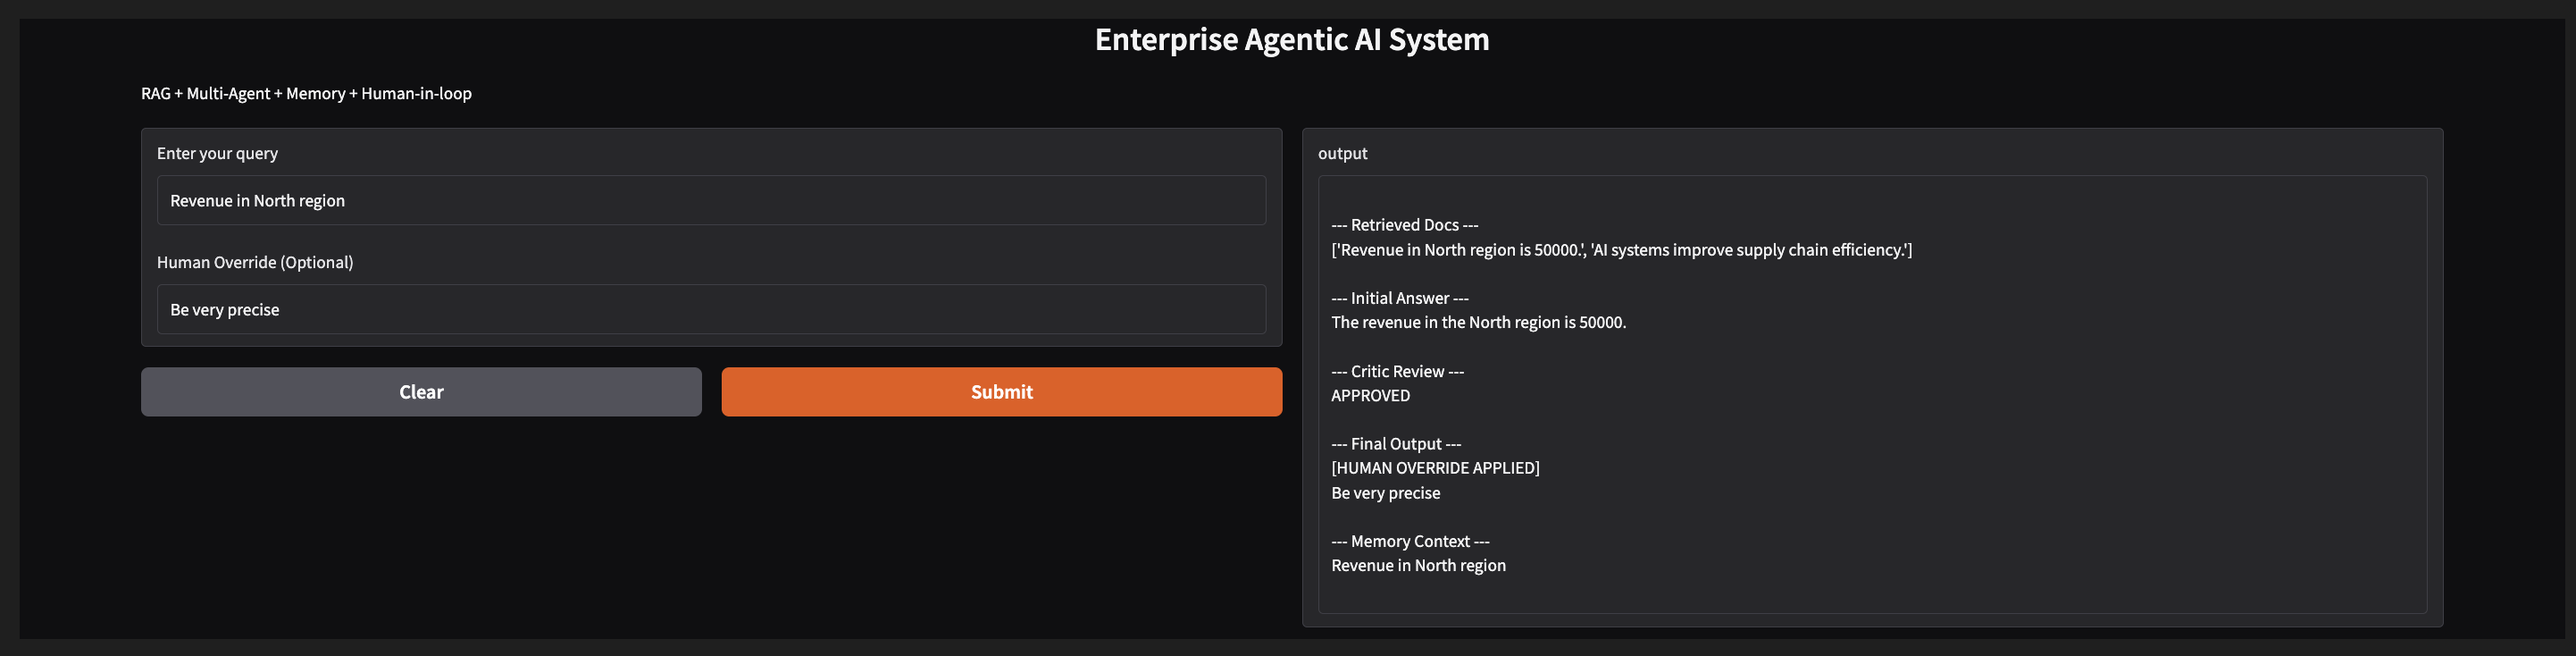

# Happy Learning